In [27]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples = 100,
                           n_features = 2,
                           n_informative = 1,
                           n_redundant = 0,
                           n_classes = 2,
                           n_clusters_per_class = 1,
                           random_state = 41,
                           hypercube = False,
                           class_sep = 15)

In [28]:
print(X.shape)
print(y.shape)

(100, 2)
(100,)


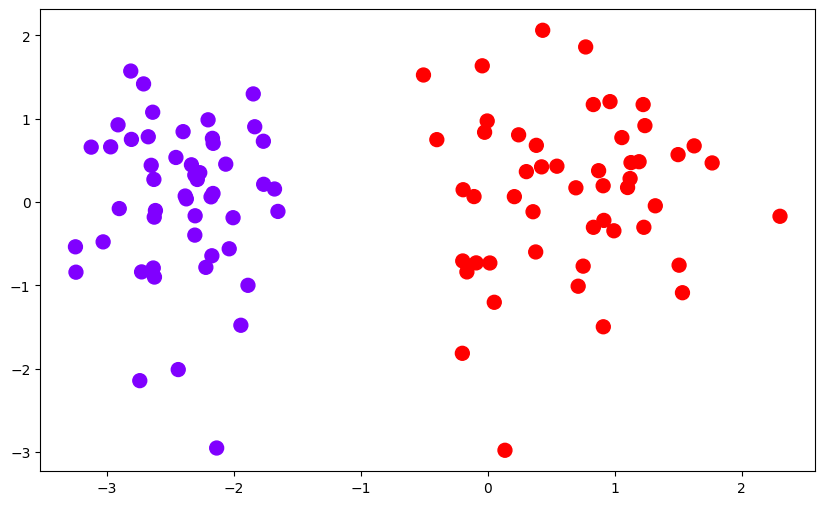

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 6))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'rainbow', s = 100)

In [30]:
def perceptron(X, y):
  w1 = w2 = b = 1
  lr = 0.1

  for i in range(1000):
    for j in range(X.shape[0]):
      z = w1 * X[j][0] + w2 * X[j][1] + b
      if z * y[j] < 0:
        w1 = w1 + lr * y[j] * X[j][0]
        w2 = w2 + lr * y[j] * X[j][1]
        b = b + lr * y[j]
  return w1, w2, b

In [11]:
w1, w2, b = perceptron(X, y)

In [12]:
print(w1)
print(w2)
print(b)

1.006638570722407
0.22215119727529098
1.3000000000000003


In [13]:
m = -(w1 / w2)
c = -(b / w2)

(-3.0, 2.0)

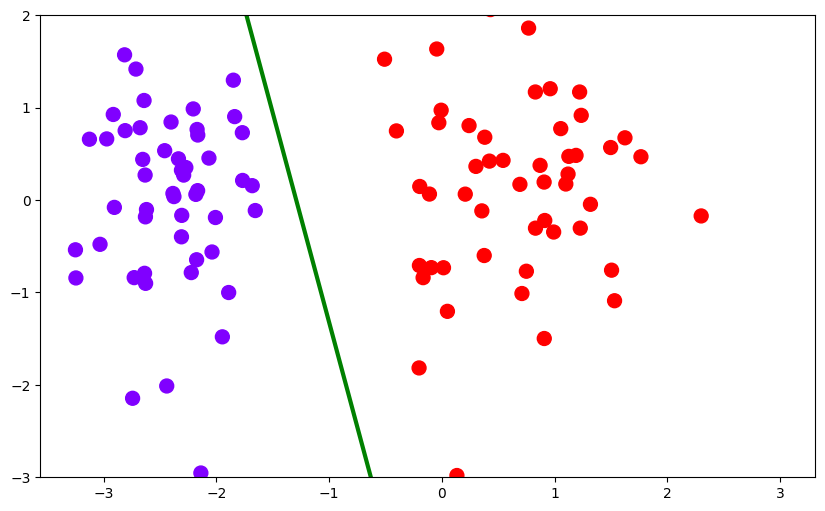

In [15]:
x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + c
plt.figure(figsize = (10, 6))
plt.plot(x_input, y_input, color = 'green', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'rainbow', s = 100)
plt.ylim(-3,2)

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
or_data = pd.DataFrame()
and_data = pd.DataFrame()
xor_data = pd.DataFrame()

In [3]:
or_data['input1'] = [1,1,0,0]
or_data['input2'] = [1,0,1,0]
or_data['output'] = [1,1,1,0]

In [4]:
and_data['input1'] = [1,1,0,0]
and_data['input2'] = [1,0,1,0]
and_data['output'] = [1,0,0,0]

In [5]:
xor_data['input1'] = [1,1,0,0]
xor_data['input2'] = [1,0,1,0]
xor_data['output'] = [0,1,1,0]

In [6]:
and_data

,input1,input2,output
0,1,1,1
1,1,0,0
2,0,1,0
3,0,0,0


<Axes: xlabel='input1', ylabel='input2'>

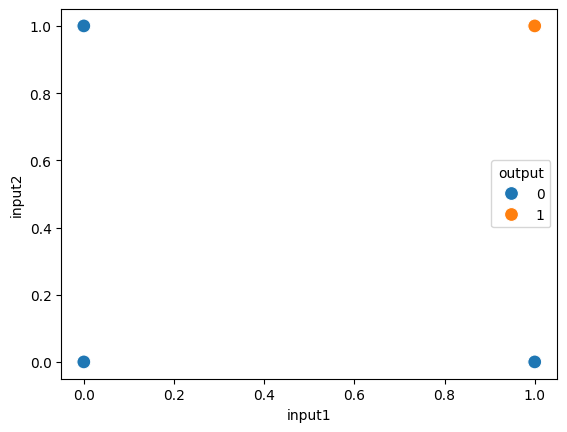

In [8]:
sns.scatterplot(x=and_data['input1'], y=and_data['input2'], hue = and_data['output'], s = 100)

In [9]:
or_data

,input1,input2,output
0,1,1,1
1,1,0,1
2,0,1,1
3,0,0,0


<Axes: xlabel='input1', ylabel='input2'>

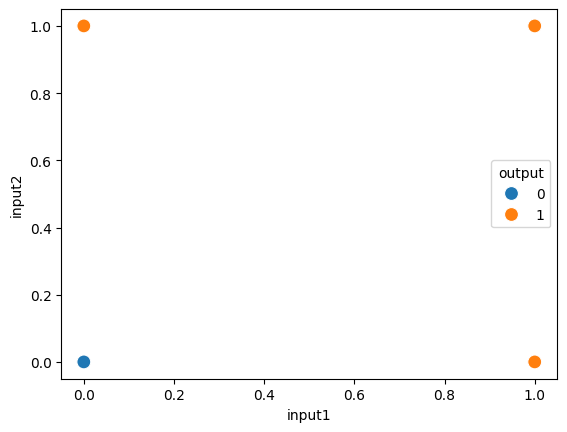

In [10]:
sns.scatterplot(x=or_data['input1'], y=or_data['input2'], hue = or_data['output'], s=100)

In [11]:
xor_data

,input1,input2,output
0,1,1,0
1,1,0,1
2,0,1,1
3,0,0,0


<Axes: xlabel='input1', ylabel='input2'>

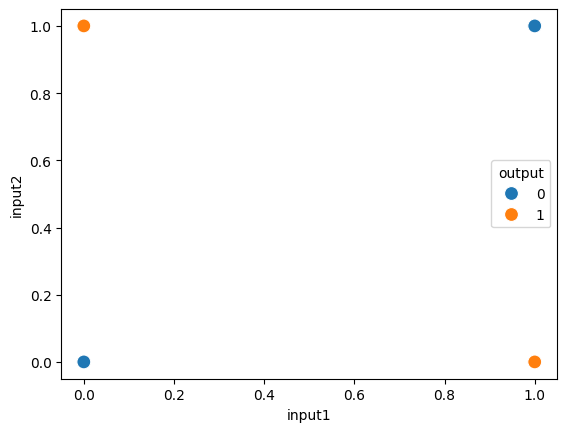

In [12]:
sns.scatterplot(x=xor_data['input1'], y=xor_data['input2'], hue=xor_data['output'], s=100)

In [13]:
from sklearn.linear_model import Perceptron

In [15]:
clf1 = Perceptron()
clf2 = Perceptron()
clf3 = Perceptron()

In [17]:
clf1.fit(and_data.iloc[:, 0:2].values, and_data.iloc[:, -1].values)
clf2.fit(or_data.iloc[:, 0:2].values, or_data.iloc[:, -1].values)
clf3.fit(xor_data.iloc[:, 0:2].values, xor_data.iloc[:, -1].values)

Perceptron()

In [18]:
clf1.coef_

array([[2., 2.]])

In [19]:
clf1.intercept_

array([-2.])

In [38]:
x = np.linspace(and_data['input1'].min()-1,
                and_data['input2'].max()+1, 100)
y = -x + 1

<Axes: xlabel='input1', ylabel='input2'>

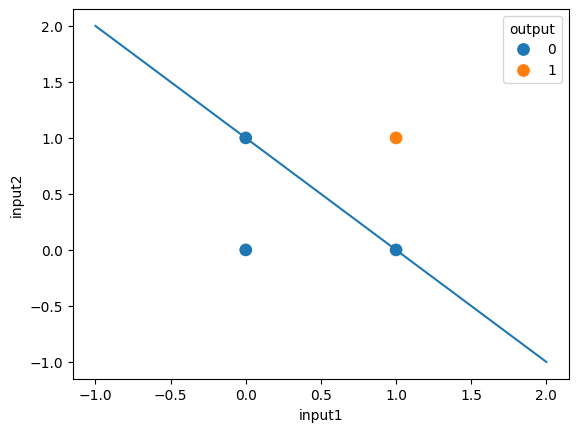

In [39]:
plt.plot(x, y)
sns.scatterplot(x=and_data['input1'], y=and_data['input2'], hue = and_data['output'], s = 100)

In [40]:
clf2.coef_

array([[2., 2.]])

In [41]:
clf2.intercept_

array([-1.])

In [42]:
x = np.linspace(or_data['input1'].min()-1,
                or_data['input2'].max()+1, 100)
y = -x + 0.5

<Axes: xlabel='input1', ylabel='input2'>

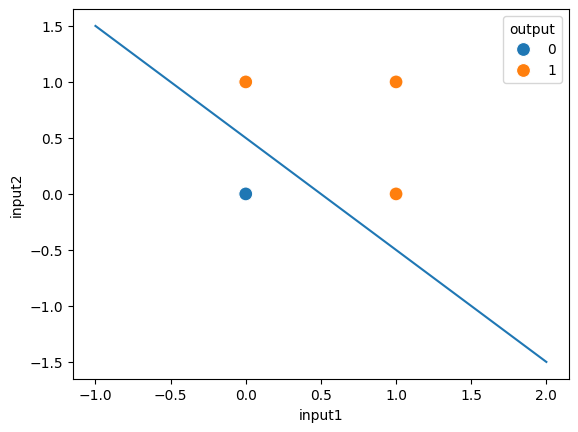

In [44]:
plt.plot(x, y)
sns.scatterplot(x=or_data['input1'], y=or_data['input2'], hue=or_data['output'], s=100)

In [45]:
clf3.coef_

array([[0., 0.]])

In [46]:
clf3.intercept_

array([0.])

In [50]:
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions

<Axes: >

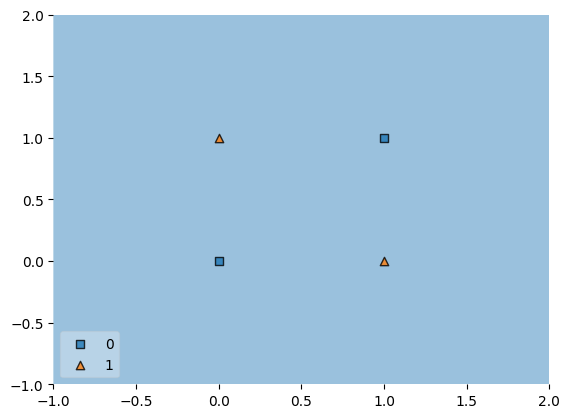

In [51]:
plot_decision_regions(xor_data.iloc[:, 0:2].values, xor_data.iloc[:, -1].values, clf = clf3, legend = 3)